In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
tickers = [ 'AAPL', 'JPM', 'GS', 'BAC', 'MS']
data = yf.download(tickers, start='2023-01-01', end='2025-01-01')['Close']

returns = data.pct_change().dropna()

print("Data downloaded")
print("Shape:", data.shape)

[*********************100%***********************]  5 of 5 completed

Data downloaded
Shape: (502, 5)


In [4]:
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_list = []

for i in range(num_portfolios):
    # Generate random weights that add up to 100%
    w = np.random.random(len(tickers))
    w /= w.sum()
    weights_list.append(w)

    # Annualized return
    p_return = np.sum(returns.mean() * w) * 252

    # Annualized volatility 
    p_volatility = np. sqrt(np.dot(w.T, np.dot(returns.cov() * 252, w)))

    # Sharpe ratio
    p_sharpe = p_return / p_volatility

    results[0, i] = p_return
    results[1, i] = p_volatility
    results[2, i] = p_sharpe

print("Simulation complete!")
print(f"Portfolios simulated: {num_portfolios}")

Simulation complete!
Portfolios simulated: 5000


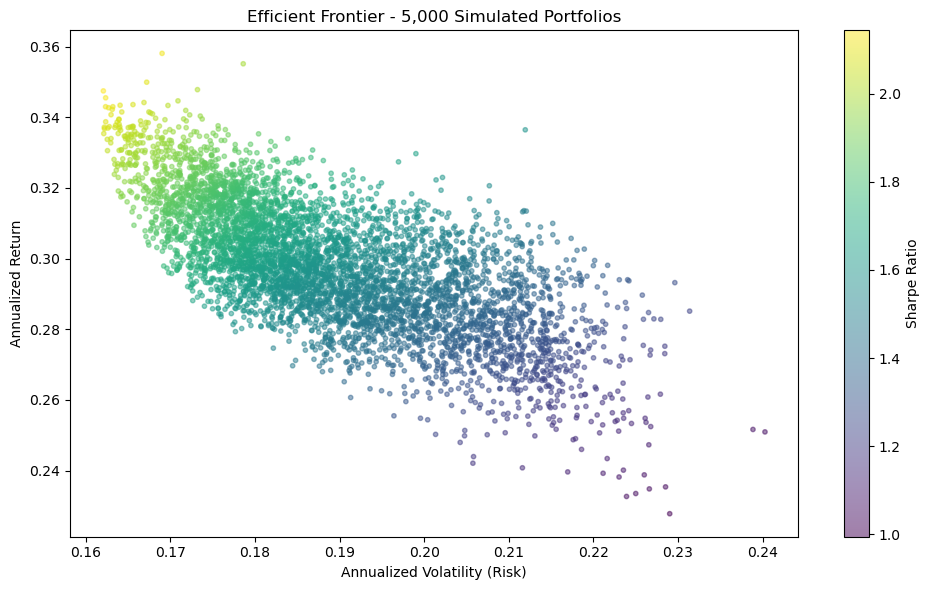

Chart saved!


In [6]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(results[1], results[0],
                      c=results[2], cmap='viridis',
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier - 5,000 Simulated Portfolios')
plt.tight_layout()
plt.savefig('../outputs/efficient_frontier.png')
plt.show()

print("Chart saved!")

In [8]:
# Finding the portfolio with the highest Sharpe Ratio
best_idx = np.argmax(results[2])
best_return = results[0, best_idx]
best_volatility = results[1, best_idx]
best_sharpe = results[2, best_idx]
best_weights = weights_list[best_idx]

print("Best Portfolio Found")
print(f"Expected Annual Return: {best_return:.2%}")
print(f"Annual Volatility: {best_volatility:.2%}")
print(f"Sharpe Ratio: {best_sharpe:.2f}")
print()
print("Optimal Weights:")
for ticker, weight in zip(tickers, best_weights):
    print(f"   {ticker}: {weight:.2%}")

Best Portfolio Found
Expected Annual Return: 34.74%
Annual Volatility: 16.21%
Sharpe Ratio: 2.14

Optimal Weights:
   AAPL: 47.31%
   JPM: 4.48%
   GS: 8.43%
   BAC: 38.17%
   MS: 1.60%


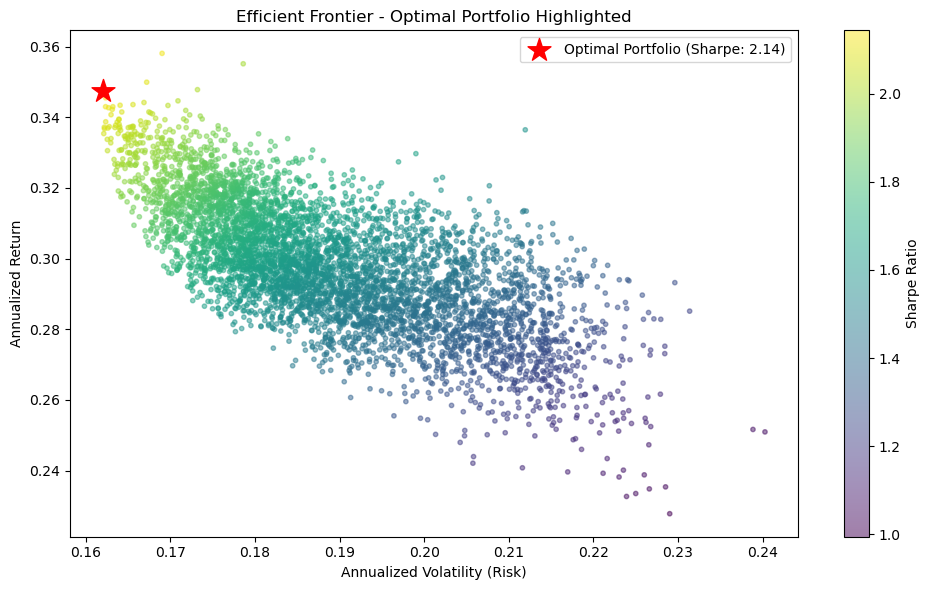

Chart saved


In [11]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(results[1], results[0],
                      c=results[2], cmap='viridis',
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight the best portfolio with a red star
plt.scatter(best_volatility, best_return,
            color='red', marker='*', s=300,
            label=f'Optimal Portfolio (Sharpe: {best_sharpe:.2f})')

plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier - Optimal Portfolio Highlighted')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/efficient_frontier_optimal.png')
plt.show()

print("Chart saved")

In [ ]:
# Create a summary table
summary = pd.DataFrame({
    'Ticker': tickers,
    'Optimal Weight': [f"{w:.2%}" for w in best_weights],
})

print("Optimal Portfolio Allocation:")
print(summary.to_string(index=False))
print()
print(f"If you invested $100,000:")
for ticker, weight in zip(tickers, best_weights):
    dollar_amount = weight * 100000
    print(f"   {ticker}: ${do